In [1]:
import pandas as pd 
df = pd.read_csv("./tables/reviews.csv")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

directors = pd.read_csv("./tables/directors.csv")
actors    = pd.read_csv("./tables/actors.csv")
users     = pd.read_csv("./tables/users.csv")
movies    = pd.read_csv("./tables/movies.csv")
roles     = pd.read_csv("./tables/roles.csv")
reviews   = pd.read_csv("./tables/reviews.csv")

users["registrationDate"] = pd.to_datetime(users["registrationDate"])
reviews["reviewDate"]     = pd.to_datetime(reviews["reviewDate"])

TABLES = {
    "directors": directors,
    "actors":    actors,
    "users":     users,
    "movies":    movies,
    "roles":     roles,
    "reviews":   reviews,
}

PASS = "✅ PASS"
FAIL = "❌ FAIL"

def result(ok, detail=""):
    tag = PASS if ok else FAIL
    return f"{tag}  {detail}".strip()

print("Tables loaded:")
for name, df in TABLES.items():
    print(f"  {name:<12} {len(df):>8,} rows  ×  {df.shape[1]} cols")

Tables loaded:
  directors       1,000 rows  ×  3 cols
  actors          5,000 rows  ×  4 cols
  users          50,000 rows  ×  4 cols
  movies         10,000 rows  ×  6 cols
  roles         200,000 rows  ×  3 cols
  reviews       150,000 rows  ×  5 cols


In [3]:
print("=" * 60)
print("CHECK 1 · COMPLETENESS  (no NULLs / NaNs)")
print("=" * 60)

all_pass = True
for name, df in TABLES.items():
    null_counts = df.isnull().sum()
    any_null    = null_counts.any()
    if any_null:
        all_pass = False
        bad_cols = null_counts[null_counts > 0].to_dict()
        print(f"  {name:<12}  {FAIL}  null columns → {bad_cols}")
    else:
        print(f"  {name:<12}  {PASS}  0 nulls across {df.shape[1]} columns")

print()
print("Overall:", PASS if all_pass else FAIL)

CHECK 1 · COMPLETENESS  (no NULLs / NaNs)
  directors     ✅ PASS  0 nulls across 3 columns
  actors        ✅ PASS  0 nulls across 4 columns
  users         ✅ PASS  0 nulls across 4 columns
  movies        ✅ PASS  0 nulls across 6 columns
  roles         ✅ PASS  0 nulls across 3 columns
  reviews       ✅ PASS  0 nulls across 5 columns

Overall: ✅ PASS


In [4]:
print("=" * 60)
print("CHECK 2 · UNIQUENESS  (primary-key columns)")
print("=" * 60)

pk_checks = [
    ("directors", "directorID"),
    ("actors",    "actorID"),
    ("users",     "userID"),
    ("movies",    "movieID"),
    ("reviews",   "reviewID"),
]

all_pass = True
for tname, col in pk_checks:
    df   = TABLES[tname]
    dups = df[col].duplicated().sum()
    ok   = dups == 0
    all_pass &= ok
    print(f"  {tname:<12} [{col}]  {result(ok, f'{dups} duplicates')}")

combo_dups = roles.duplicated(subset=["movieID", "actorID"]).sum()
ok = combo_dups == 0
all_pass &= ok
print(f"  {'roles':<12} [(movieID,actorID)]  {result(ok, f'{combo_dups} duplicates')}")

print()
print("Overall:", PASS if all_pass else FAIL)

CHECK 2 · UNIQUENESS  (primary-key columns)
  directors    [directorID]  ✅ PASS  0 duplicates
  actors       [actorID]  ✅ PASS  0 duplicates
  users        [userID]  ✅ PASS  0 duplicates
  movies       [movieID]  ✅ PASS  0 duplicates
  reviews      [reviewID]  ✅ PASS  0 duplicates
  roles        [(movieID,actorID)]  ✅ PASS  0 duplicates

Overall: ✅ PASS


In [5]:
print("=" * 60)
print("CHECK 3 · DOMAIN VALIDITY  (values within declared ranges)")
print("=" * 60)

checks = [
    ("directors.birthYear",  directors["birthYear"],  1880, 1990, ""),
    ("actors.birthYear",     actors["birthYear"],     1900, 2016, ""),
    ("movies.releaseDate",   movies["releaseDate"],   1920, 2026, ""),
    ("movies.duration (min)",movies["duration"],      60,   225,  ""),
    ("reviews.rating",       reviews["rating"],       1,    10,   ""),
]

all_pass = True
for label, series, lo, hi, _ in checks:
    out_of_range = ((series < lo) | (series > hi)).sum()
    ok = out_of_range == 0
    all_pass &= ok
    print(f"  {label:<30}  range [{lo}, {hi}]  {result(ok, f'{out_of_range} violations')}")

reg_lo, reg_hi = pd.Timestamp("2005-12-15"), pd.Timestamp("2026-03-15")
bad_reg = ((users["registrationDate"] < reg_lo) | (users["registrationDate"] > reg_hi)).sum()
ok = bad_reg == 0
all_pass &= ok
print(f"  {'users.registrationDate':<30}  range [2005-12-15, 2026-03-15]  {result(ok, f'{bad_reg} violations')}")

rev_hi = pd.Timestamp("2026-03-23")
bad_rev = (reviews["reviewDate"] > rev_hi).sum()
ok = bad_rev == 0
all_pass &= ok
print(f"  {'reviews.reviewDate':<30}  upper bound 2026-03-23  {result(ok, f'{bad_rev} violations')}")

print()
print("Overall:", PASS if all_pass else FAIL)

CHECK 3 · DOMAIN VALIDITY  (values within declared ranges)
  directors.birthYear             range [1880, 1990]  ✅ PASS  0 violations
  actors.birthYear                range [1900, 2016]  ✅ PASS  0 violations
  movies.releaseDate              range [1920, 2026]  ✅ PASS  0 violations
  movies.duration (min)           range [60, 225]  ✅ PASS  0 violations
  reviews.rating                  range [1, 10]  ✅ PASS  0 violations
  users.registrationDate          range [2005-12-15, 2026-03-15]  ✅ PASS  0 violations
  reviews.reviewDate              upper bound 2026-03-23  ✅ PASS  0 violations

Overall: ✅ PASS


In [6]:
print("=" * 60)
print("CHECK 4 · REFERENTIAL INTEGRITY  (FK → PK)")
print("=" * 60)

fk_checks = [
    ("movies",  "directorID", "directors", "directorID"),
    ("roles",   "movieID",    "movies",    "movieID"),
    ("roles",   "actorID",    "actors",    "actorID"),
    ("reviews", "movieID",    "movies",    "movieID"),
    ("reviews", "userID",     "users",     "userID"),
]

all_pass = True
for child_t, fk_col, parent_t, pk_col in fk_checks:
    child_vals  = set(TABLES[child_t][fk_col])
    parent_vals = set(TABLES[parent_t][pk_col])
    orphans     = child_vals - parent_vals
    ok = len(orphans) == 0
    all_pass &= ok
    print(f"  {child_t}.{fk_col:<14} → {parent_t}.{pk_col:<14}  "
          f"{result(ok, f'{len(orphans)} orphan FK values')}")

print()
print("Overall:", PASS if all_pass else FAIL)

CHECK 4 · REFERENTIAL INTEGRITY  (FK → PK)
  movies.directorID     → directors.directorID      ✅ PASS  0 orphan FK values
  roles.movieID        → movies.movieID         ✅ PASS  0 orphan FK values
  roles.actorID        → actors.actorID         ✅ PASS  0 orphan FK values
  reviews.movieID        → movies.movieID         ✅ PASS  0 orphan FK values
  reviews.userID         → users.userID          ✅ PASS  0 orphan FK values

Overall: ✅ PASS


In [7]:
print("=" * 60)
print("CHECK 5 · BUSINESS-RULE COMPLIANCE")
print("=" * 60)

all_pass = True

merged_dir = movies.merge(directors[["directorID", "birthYear"]], on="directorID")
director_age = merged_dir["releaseDate"] - merged_dir["birthYear"]
violations_dir = (director_age < 30).sum()
ok = violations_dir == 0
all_pass &= ok
print(f"  Director ≥ 30 at release    {result(ok, f'{violations_dir} violations')}")

merged_actor = roles.merge(movies[["movieID", "releaseDate"]], on="movieID") \
                    .merge(actors[["actorID", "birthYear"]], on="actorID")
actor_age = merged_actor["releaseDate"] - merged_actor["birthYear"]
violations_act = (actor_age < 6).sum()
ok = violations_act == 0
all_pass &= ok
print(f"  Actor ≥ 6 at release         {result(ok, f'{violations_act} violations')}")

merged_rev = reviews.merge(users[["userID", "registrationDate"]], on="userID")
early_reviews = (merged_rev["reviewDate"] < merged_rev["registrationDate"]).sum()
ok = early_reviews == 0
all_pass &= ok
print(f"  Review date ≥ registration   {result(ok, f'{early_reviews} violations')}")

print()
print("Overall:", PASS if all_pass else FAIL)

CHECK 5 · BUSINESS-RULE COMPLIANCE
  Director ≥ 30 at release    ✅ PASS  0 violations
  Actor ≥ 6 at release         ✅ PASS  0 violations
  Review date ≥ registration   ✅ PASS  0 violations

Overall: ✅ PASS


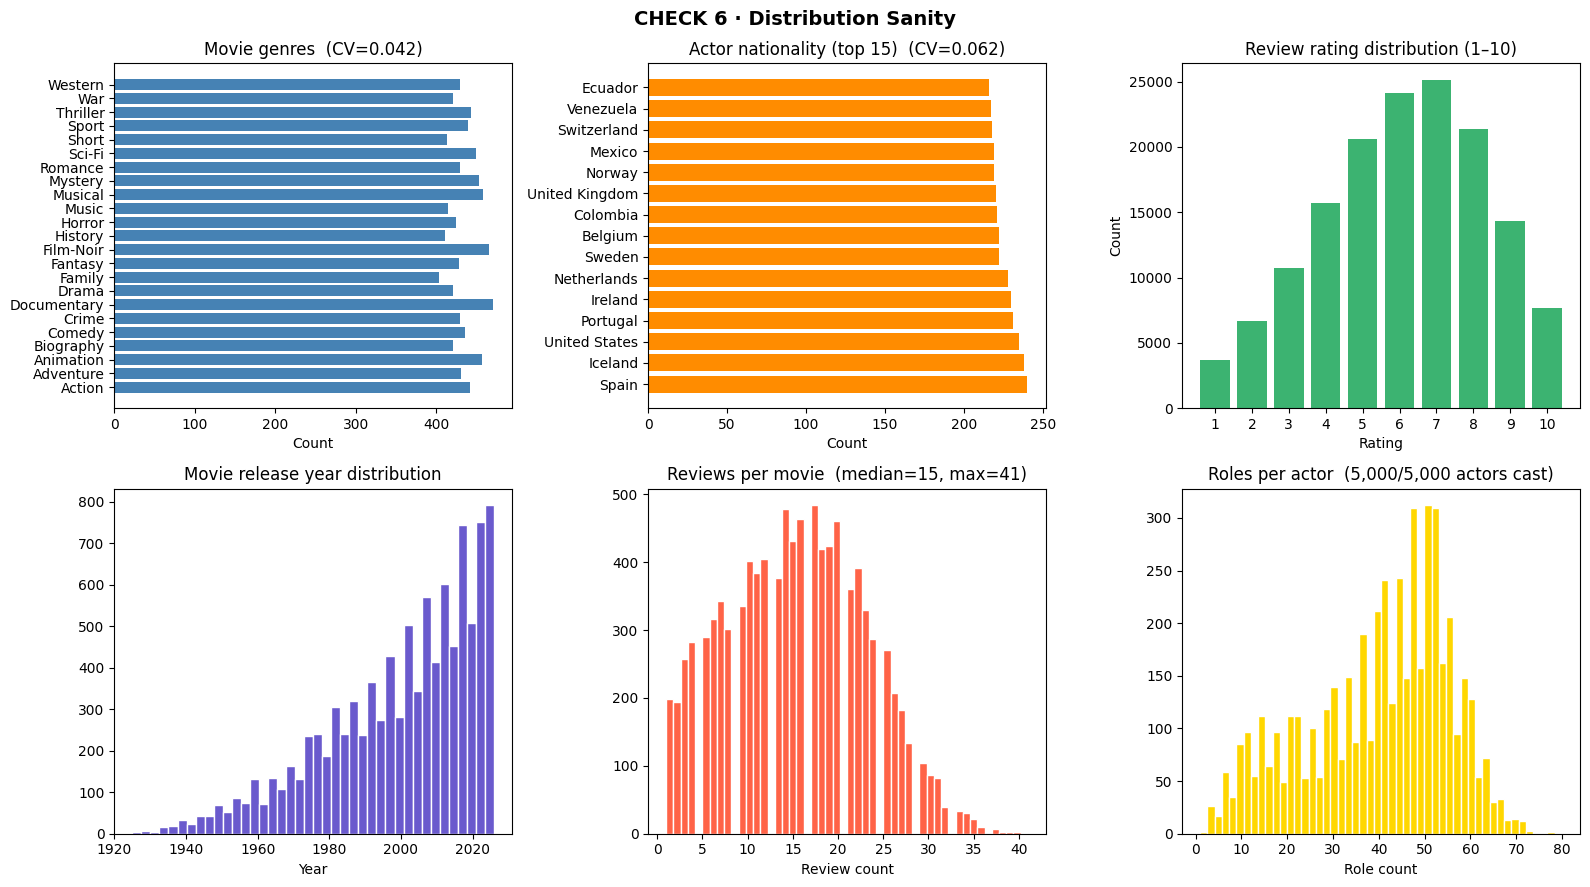


── Numeric summary ──────────────────────────────────────────
  Genre CV (lower = more uniform):          0.0416
  Rating mean ± std:                        6.08 ± 2.22
  Movies with ≥1 review:                    9,834 / 10,000 (98.3%)
  Actors with ≥1 role:                      5,000 / 5,000 (100.0%)
  Avg reviews per movie:                    15.3
  Avg roles per actor:                      40.0
  User registration date range:             2005-12-15 → 2026-03-15


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("CHECK 6 · Distribution Sanity", fontsize=14, fontweight="bold")

ax = axes[0, 0]
genre_counts = movies["genre"].value_counts().sort_index()
ax.barh(genre_counts.index, genre_counts.values, color="steelblue")
ax.set_title("Movie genre distribution")
ax.set_xlabel("Count")
expected_per_genre = len(movies) / movies["genre"].nunique()
cv = genre_counts.std() / genre_counts.mean()
ax.set_title(f"Movie genres  (CV={cv:.3f})")

ax = axes[0, 1]
nat_counts = actors["nationality"].value_counts()
ax.barh(nat_counts.index[:15], nat_counts.values[:15], color="darkorange")
ax.set_title(f"Actor nationality (top 15)  (CV={nat_counts.std()/nat_counts.mean():.3f})")
ax.set_xlabel("Count")

ax = axes[0, 2]
rating_counts = reviews["rating"].value_counts().sort_index()
ax.bar(rating_counts.index, rating_counts.values, color="mediumseagreen")
ax.set_title("Review rating distribution (1–10)")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax = axes[1, 0]
ax.hist(movies["releaseDate"], bins=40, color="slateblue", edgecolor="white")
ax.set_title("Movie release year distribution")
ax.set_xlabel("Year")

ax = axes[1, 1]
reviews_per_movie = reviews.groupby("movieID").size()
ax.hist(reviews_per_movie, bins=50, color="tomato", edgecolor="white")
ax.set_title(f"Reviews per movie  (median={reviews_per_movie.median():.0f}, "
             f"max={reviews_per_movie.max()})")
ax.set_xlabel("Review count")

ax = axes[1, 2]
roles_per_actor = roles.groupby("actorID").size()
actors_with_roles = roles["actorID"].nunique()
ax.hist(roles_per_actor, bins=50, color="gold", edgecolor="white")
ax.set_title(f"Roles per actor  ({actors_with_roles:,}/{len(actors):,} actors cast)")
ax.set_xlabel("Role count")

plt.tight_layout()
plt.show()

print("\n── Numeric summary ──────────────────────────────────────────")
print(f"  Genre CV (lower = more uniform):          {cv:.4f}")
print(f"  Rating mean ± std:                        "
      f"{reviews['rating'].mean():.2f} ± {reviews['rating'].std():.2f}")
print(f"  Movies with ≥1 review:                    "
      f"{reviews['movieID'].nunique():,} / {len(movies):,} "
      f"({reviews['movieID'].nunique()/len(movies)*100:.1f}%)")
print(f"  Actors with ≥1 role:                      "
      f"{roles['actorID'].nunique():,} / {len(actors):,} "
      f"({roles['actorID'].nunique()/len(actors)*100:.1f}%)")
print(f"  Avg reviews per movie:                    {reviews_per_movie.mean():.1f}")
print(f"  Avg roles per actor:                      {roles_per_actor.mean():.1f}")
print(f"  User registration date range:             "
      f"{users['registrationDate'].min().date()} → {users['registrationDate'].max().date()}")